In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

# Image Preprocessing

## Upload image

In [15]:
img = cv2.imread('cat.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

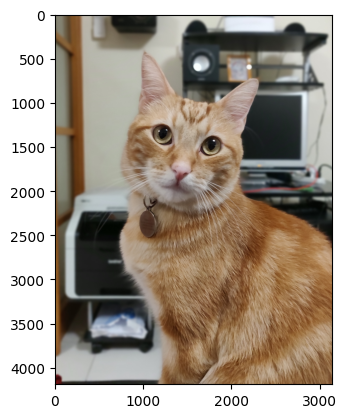

In [16]:
plt.imshow(img)

## resize and padding

In [17]:
height, width, ch = img.shape

w_longest =  width > height
max_side = np.max([height, width])
min_side = np.min([height, width])

In [18]:
resized_max_side = 32
resized_min_side = int(32 * min_side / max_side) if height != width else 32

In [19]:
dsize = (resized_max_side, resized_min_side) if w_longest else (resized_min_side, resized_max_side)
img_resized = cv2.resize(img, dsize, interpolation=cv2.INTER_AREA)

In [20]:
padd_tuple = (int(np.ceil((32 - resized_min_side)/2)), int((32 - resized_min_side)/2), 0, 0)

if w_longest:
  top, bottom, left, right = padd_tuple
else:
  left, right, top, bottom = padd_tuple

(32, 32, 3)

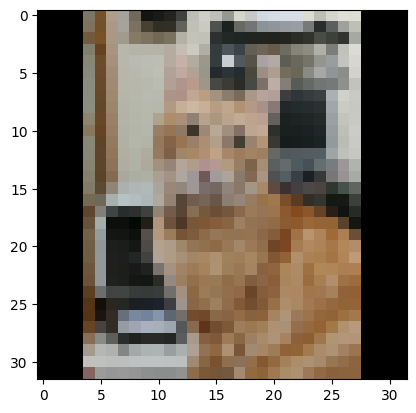

In [21]:
img_prepr = cv2.copyMakeBorder(img_resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=0)
plt.imshow(img_prepr)
img_prepr.shape

# Prediction

In [22]:
#load the model
imgclf_resnet50_model = keras.models.load_model("imgclf_resnet50_cifar10_v1.keras")

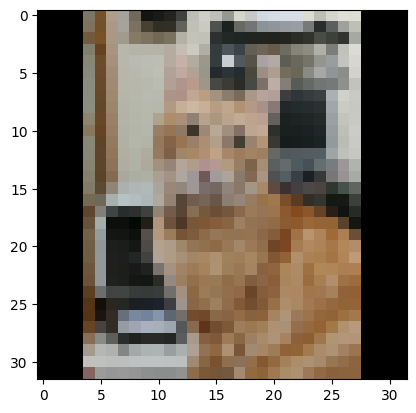

In [23]:
plt.imshow(img_prepr)

In [24]:
img_prepr_resnet = resnet_preprocess(img_prepr)

img_prepr_resnet = np.array([img_prepr_resnet])

class_prob = imgclf_resnet50_model.predict(img_prepr_resnet)
class_pred = np.argmax(class_prob, axis=1)

class_names = {
    0:"airplane", 
    1:"automobile", 
    2:"bird", 
    3:"cat", 
    4:"deer",
    5:"dog", 
    6:"frog", 
    7:"horse", 
    8:"ship", 
    9:"truck"
}

class_names[int(class_pred[0])]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


'cat'